# Notebook 04 — Analysis & Charts
**AIRI: AI Readiness Index for UK Debt Management Institutions**

**Purpose:** Produce all dissertation-quality charts at 300dpi and run the full sensitivity analysis. All outputs saved to `outputs/charts/` and `outputs/reports/`.

**Completion criterion:** All charts exported to `outputs/charts/` at 300dpi; sensitivity table produced; MASC < 2.0 confirms index robustness.

---

## Cell 1 — Imports & Global Seed

In [1]:
import random
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import shap

warnings.filterwarnings('ignore')

# ── Global seed ───────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ── Path setup — run from project root (airi-project/) ───────────────
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

CHARTS_DIR  = PROJECT_ROOT / 'outputs' / 'charts'
REPORTS_DIR = PROJECT_ROOT / 'outputs' / 'reports'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Dissertation plot style — clean, professional ─────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'savefig.dpi':       300,
    'axes.titlesize':    14,
    'axes.labelsize':    12,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})
sns.set_style('whitegrid')

# Tier colour palette (spec Section 7.3)
TIER_COLOURS = {
    'nascent':     '#DC2626',
    'developing':  '#D97706',
    'established': '#059669',
    'leading':     '#1B3A6B',
}
TIER_ORDER = ['nascent', 'developing', 'established', 'leading']
DIM_LABELS = [
    'Data\nInfrastructure',
    'Technological\nMaturity',
    'Regulatory\nCompliance',
    'Organisational\nCapability',
    'Ethical\nGovernance',
]
DIM_COLS = ['score_d1','score_d2','score_d3','score_d4','score_d5']

print(f'Project root : {PROJECT_ROOT}')
print(f'Charts dir   : {CHARTS_DIR}')
print('Setup complete — seed 42')

Project root : /Users/bukunmi/Documents/myprojects/AIRI_PROJ
Charts dir   : /Users/bukunmi/Documents/myprojects/AIRI_PROJ/outputs/charts
Setup complete — seed 42


IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


## Cell 2 — Load Data & Models

In [2]:
from src.airi_engine import AIRIConfig, AIRIScorer

# Scored dataset
df = pd.read_csv(PROJECT_ROOT / 'data' / 'scored_institutions.csv')
print(f'Scored dataset : {df.shape}')

# Config & scorer
config = AIRIConfig(str(PROJECT_ROOT / 'airi_config.yaml'))
scorer = AIRIScorer(config)

# XGBoost model
xgb_model = joblib.load(PROJECT_ROOT / 'models' / 'xgb_model.pkl')
print(f'XGBoost model  : loaded')

# SHAP values
shap_df = pd.read_csv(PROJECT_ROOT / 'data' / 'shap_values.csv')
print(f'SHAP values    : {shap_df.shape}')

# Feature importance
feat_imp = pd.read_csv(PROJECT_ROOT / 'data' / 'feature_importance.csv')
print(f'Feature imp    : {feat_imp.shape}')

print()
print('Tier distribution:')
print(df['readiness_tier'].value_counts().reindex(TIER_ORDER).to_string())

Scored dataset : (150, 26)
XGBoost model  : loaded
SHAP values    : (30, 20)
Feature imp    : (17, 2)

Tier distribution:
readiness_tier
nascent        14
developing     62
established    60
leading        14


## Cell 3 — Chart 1: AIRI Score Distribution (Dissertation Quality)

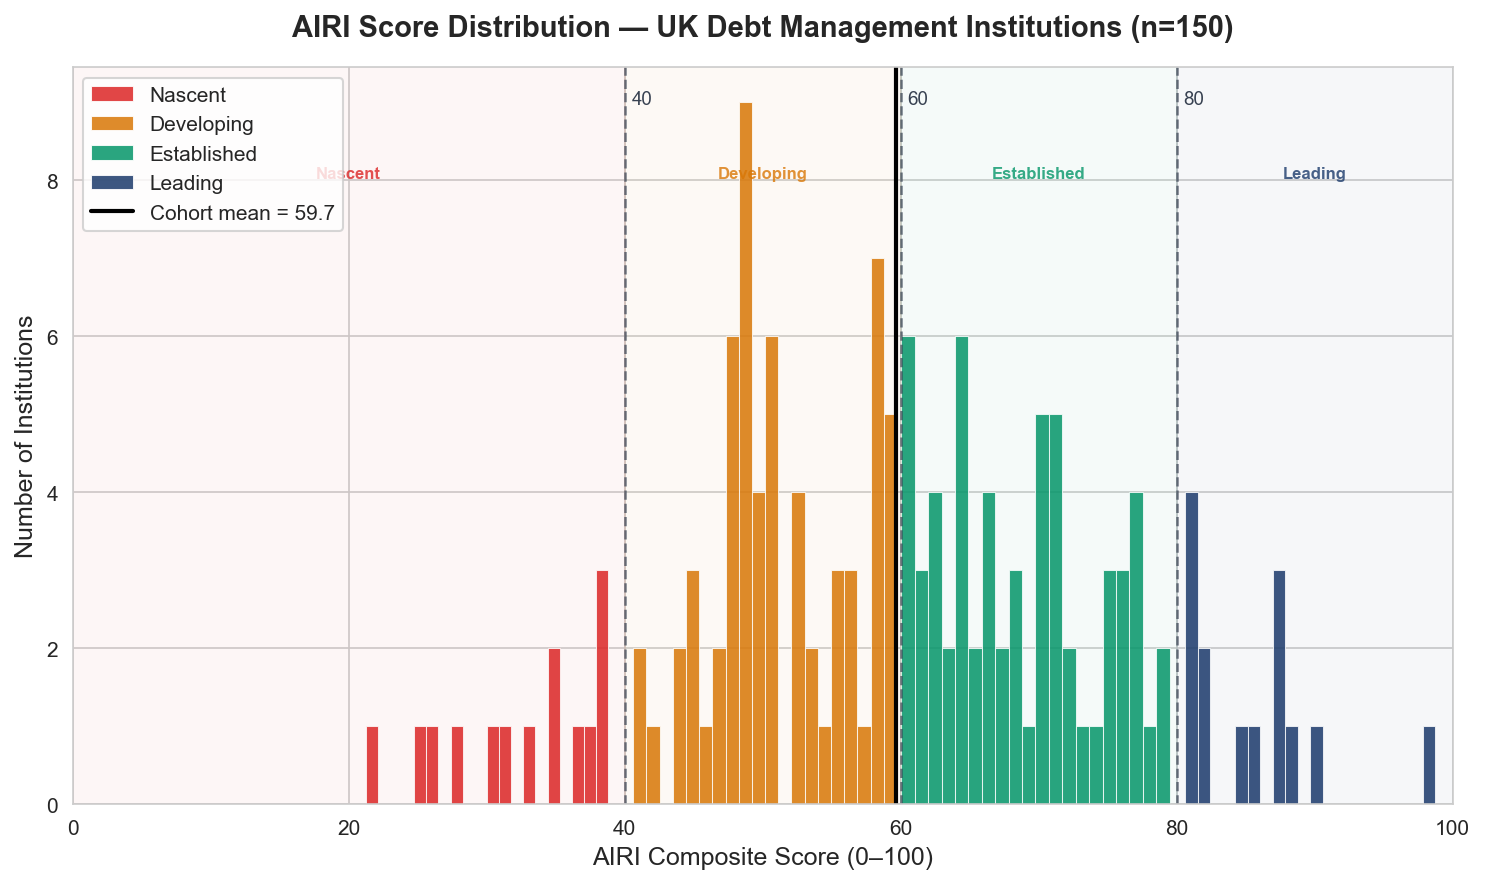

Saved: nb04_airi_score_distribution.png  (300dpi)


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

for tier in TIER_ORDER:
    subset = df[df['readiness_tier'] == tier]['airi_score']
    ax.hist(subset, bins=20, color=TIER_COLOURS[tier],
            alpha=0.85, label=tier.capitalize(), edgecolor='white', linewidth=0.5)

# Tier boundary lines
for boundary, label in [(40, '40'), (60, '60'), (80, '80')]:
    ax.axvline(boundary, color='#374151', linestyle='--',
               linewidth=1.2, alpha=0.7)
    ax.text(boundary + 0.5, ax.get_ylim()[1] * 0.95,
            label, fontsize=9, color='#374151')

mean_score = df['airi_score'].mean()
ax.axvline(mean_score, color='black', linestyle='-',
           linewidth=2, label=f'Cohort mean = {mean_score:.1f}')

ax.set_title('AIRI Score Distribution — UK Debt Management Institutions (n=150)',
             fontweight='bold', pad=15)
ax.set_xlabel('AIRI Composite Score (0–100)')
ax.set_ylabel('Number of Institutions')
ax.set_xlim(0, 100)
ax.legend(loc='upper left')

# Tier band annotations
band_info = [
    (0,  40, 'Nascent',     '#DC2626'),
    (40, 60, 'Developing',  '#D97706'),
    (60, 80, 'Established', '#059669'),
    (80, 100,'Leading',     '#1B3A6B'),
]
ymax = ax.get_ylim()[1]
for lo, hi, name, colour in band_info:
    ax.axvspan(lo, hi, alpha=0.04, color=colour)
    ax.text((lo + hi) / 2, ymax * 0.85, name,
            ha='center', fontsize=8, color=colour,
            fontweight='bold', alpha=0.8)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb04_airi_score_distribution.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: nb04_airi_score_distribution.png  (300dpi)')

## Cell 4 — Chart 2: Radar Chart — Cohort Average Dimension Scores

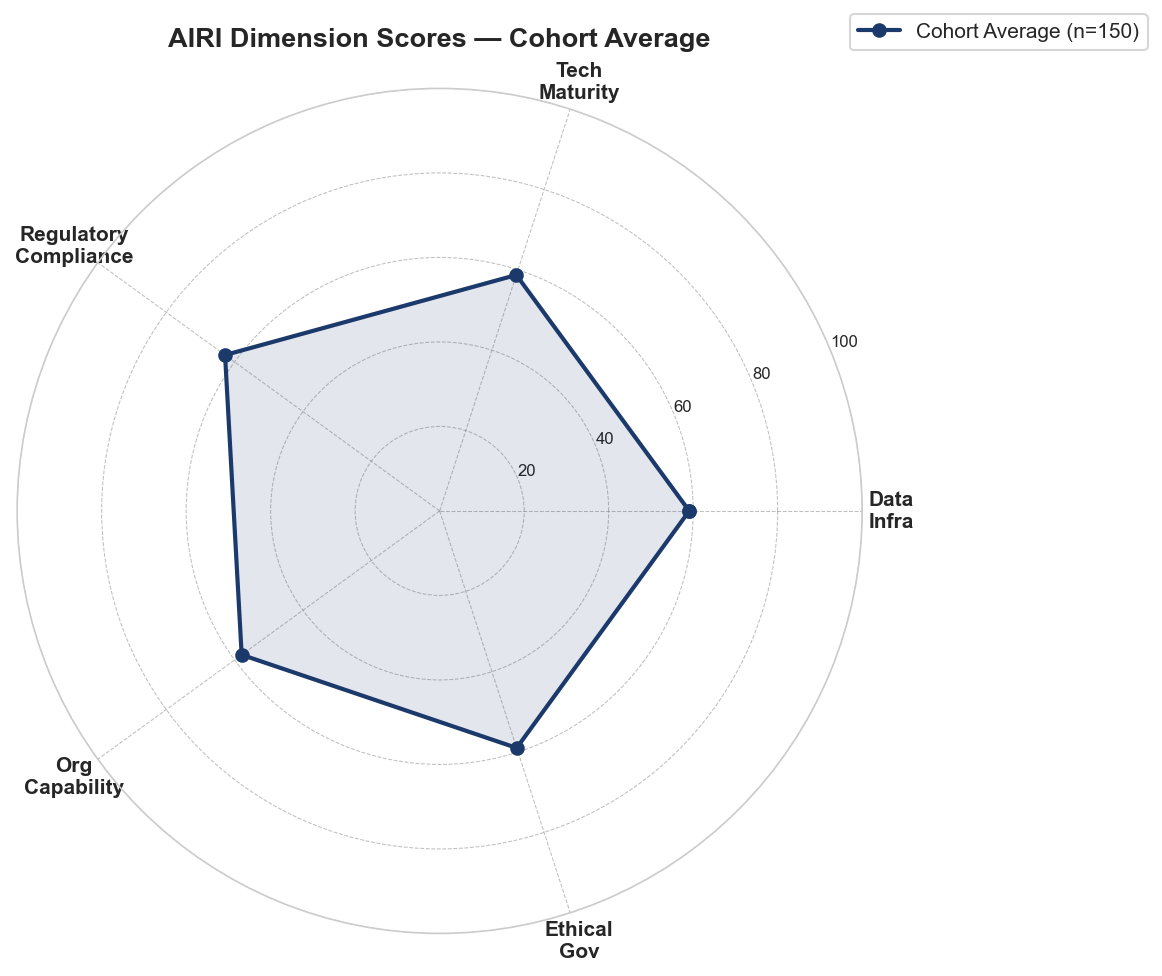

Saved: nb04_radar_cohort_average.png  (300dpi)


In [4]:
def radar_chart(values_dict, labels, title, save_path, figsize=(8, 8)):
    """Draw a radar/spider chart for dimension scores.
    values_dict: {series_name: [val1..val5]}
    """
    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=figsize,
                           subplot_kw=dict(polar=True))

    colours = ['#1B3A6B', '#DC2626', '#059669', '#D97706']
    for idx, (name, values) in enumerate(values_dict.items()):
        vals = list(values) + [values[0]]
        colour = colours[idx % len(colours)]
        ax.plot(angles, vals, 'o-', linewidth=2,
                color=colour, label=name)
        ax.fill(angles, vals, alpha=0.12, color=colour)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=10, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(['20', '40', '60', '80', '100'], size=8)
    ax.set_title(title, fontweight='bold', size=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
    ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


# Cohort average radar
cohort_means = df[DIM_COLS].mean().values
radar_labels = ['Data\nInfra', 'Tech\nMaturity',
                'Regulatory\nCompliance', 'Org\nCapability', 'Ethical\nGov']

radar_chart(
    values_dict={'Cohort Average (n=150)': cohort_means},
    labels=radar_labels,
    title='AIRI Dimension Scores — Cohort Average',
    save_path=CHARTS_DIR / 'nb04_radar_cohort_average.png',
)
print('Saved: nb04_radar_cohort_average.png  (300dpi)')

## Cell 5 — Chart 3: Radar Chart — Tier Comparison

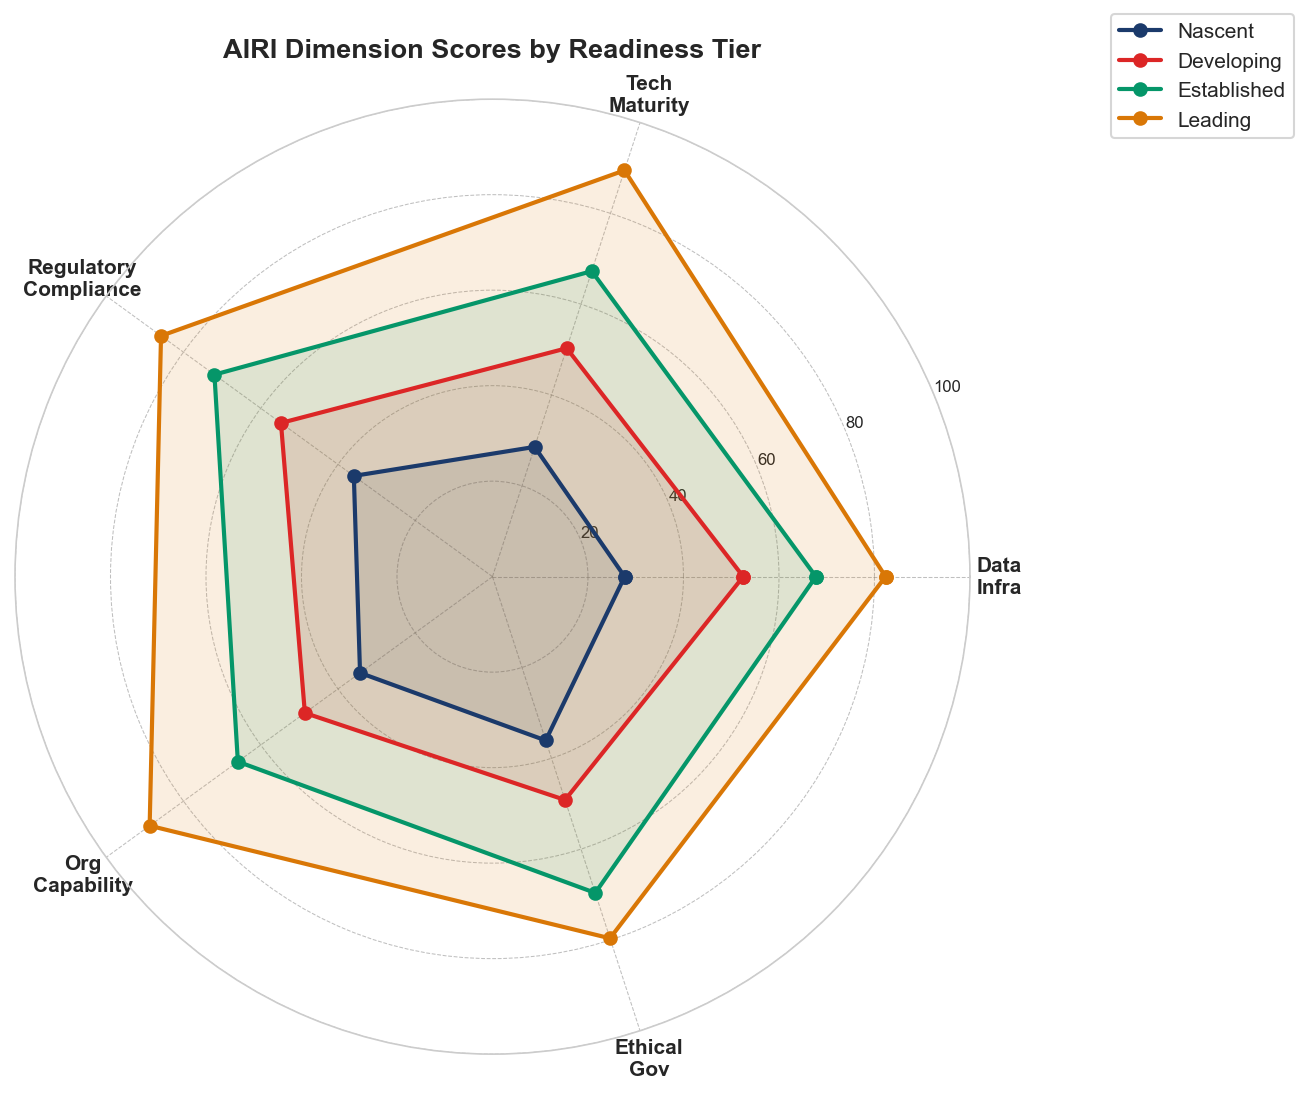

Saved: nb04_radar_tier_comparison.png  (300dpi)

Dimension means by tier:
                score_d1  score_d2  score_d3  score_d4  score_d5
readiness_tier                                                  
developing          52.5      50.3      54.8      48.6      49.2
established         67.7      67.3      72.0      65.9      69.6
leading             82.3      89.5      85.8      88.8      79.6
nascent             27.7      28.6      35.9      34.3      36.1


In [5]:
tier_dim_means = df.groupby('readiness_tier')[DIM_COLS].mean()

radar_chart(
    values_dict={
        tier.capitalize(): tier_dim_means.loc[tier].values
        for tier in TIER_ORDER
        if tier in tier_dim_means.index
    },
    labels=radar_labels,
    title='AIRI Dimension Scores by Readiness Tier',
    save_path=CHARTS_DIR / 'nb04_radar_tier_comparison.png',
    figsize=(9, 9),
)
print('Saved: nb04_radar_tier_comparison.png  (300dpi)')
print()
print('Dimension means by tier:')
print(tier_dim_means.round(1).to_string())

## Cell 6 — Chart 4: Dimension Score Heatmap by Sector

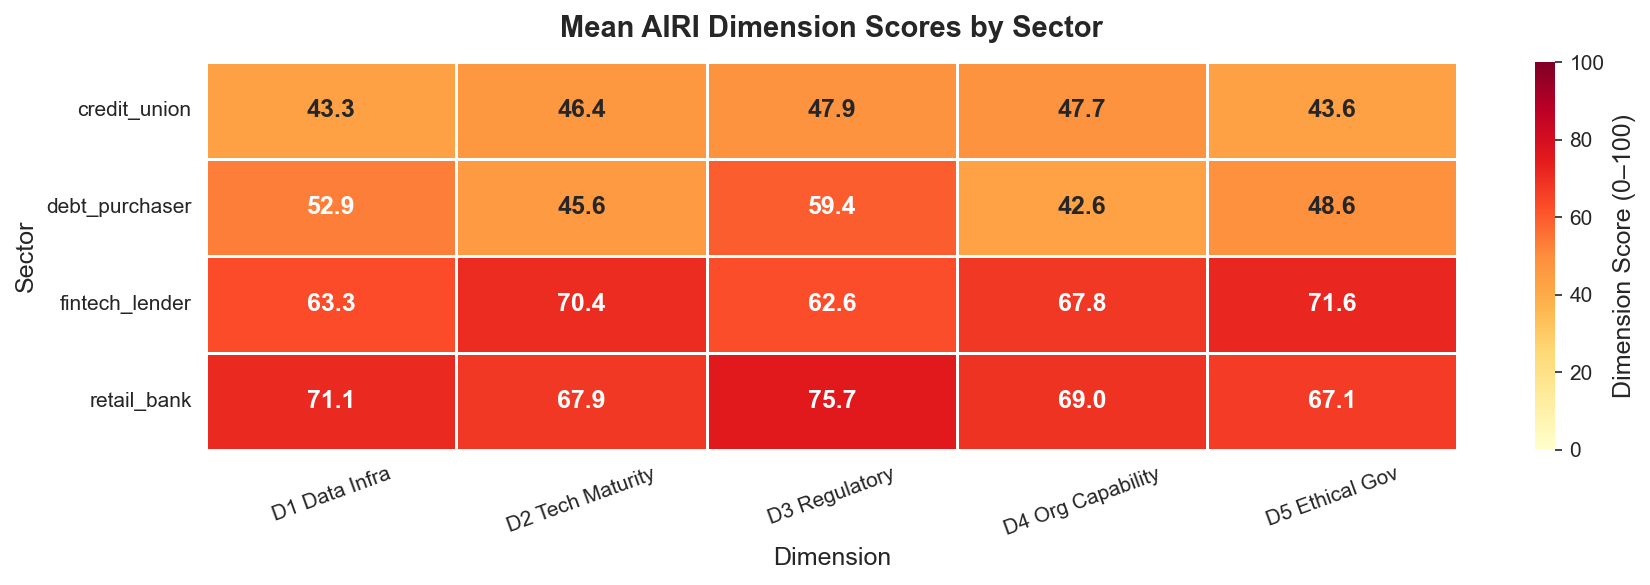

Saved: nb04_dimension_heatmap_sector.png  (300dpi)


In [6]:
sector_dim = df.groupby('sector')[DIM_COLS].mean()
sector_dim.columns = ['D1 Data Infra', 'D2 Tech Maturity',
                       'D3 Regulatory', 'D4 Org Capability', 'D5 Ethical Gov']

fig, ax = plt.subplots(figsize=(12, 4))
im = sns.heatmap(
    sector_dim,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.6, linecolor='white',
    vmin=0, vmax=100, ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'},
    cbar_kws={'label': 'Dimension Score (0–100)'}
)
ax.set_title('Mean AIRI Dimension Scores by Sector',
             fontweight='bold', fontsize=14, pad=12)
ax.set_xlabel('Dimension')
ax.set_ylabel('Sector')
ax.tick_params(axis='x', rotation=20)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb04_dimension_heatmap_sector.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: nb04_dimension_heatmap_sector.png  (300dpi)')

## Cell 7 — Chart 5: SHAP Summary (Dissertation Quality)

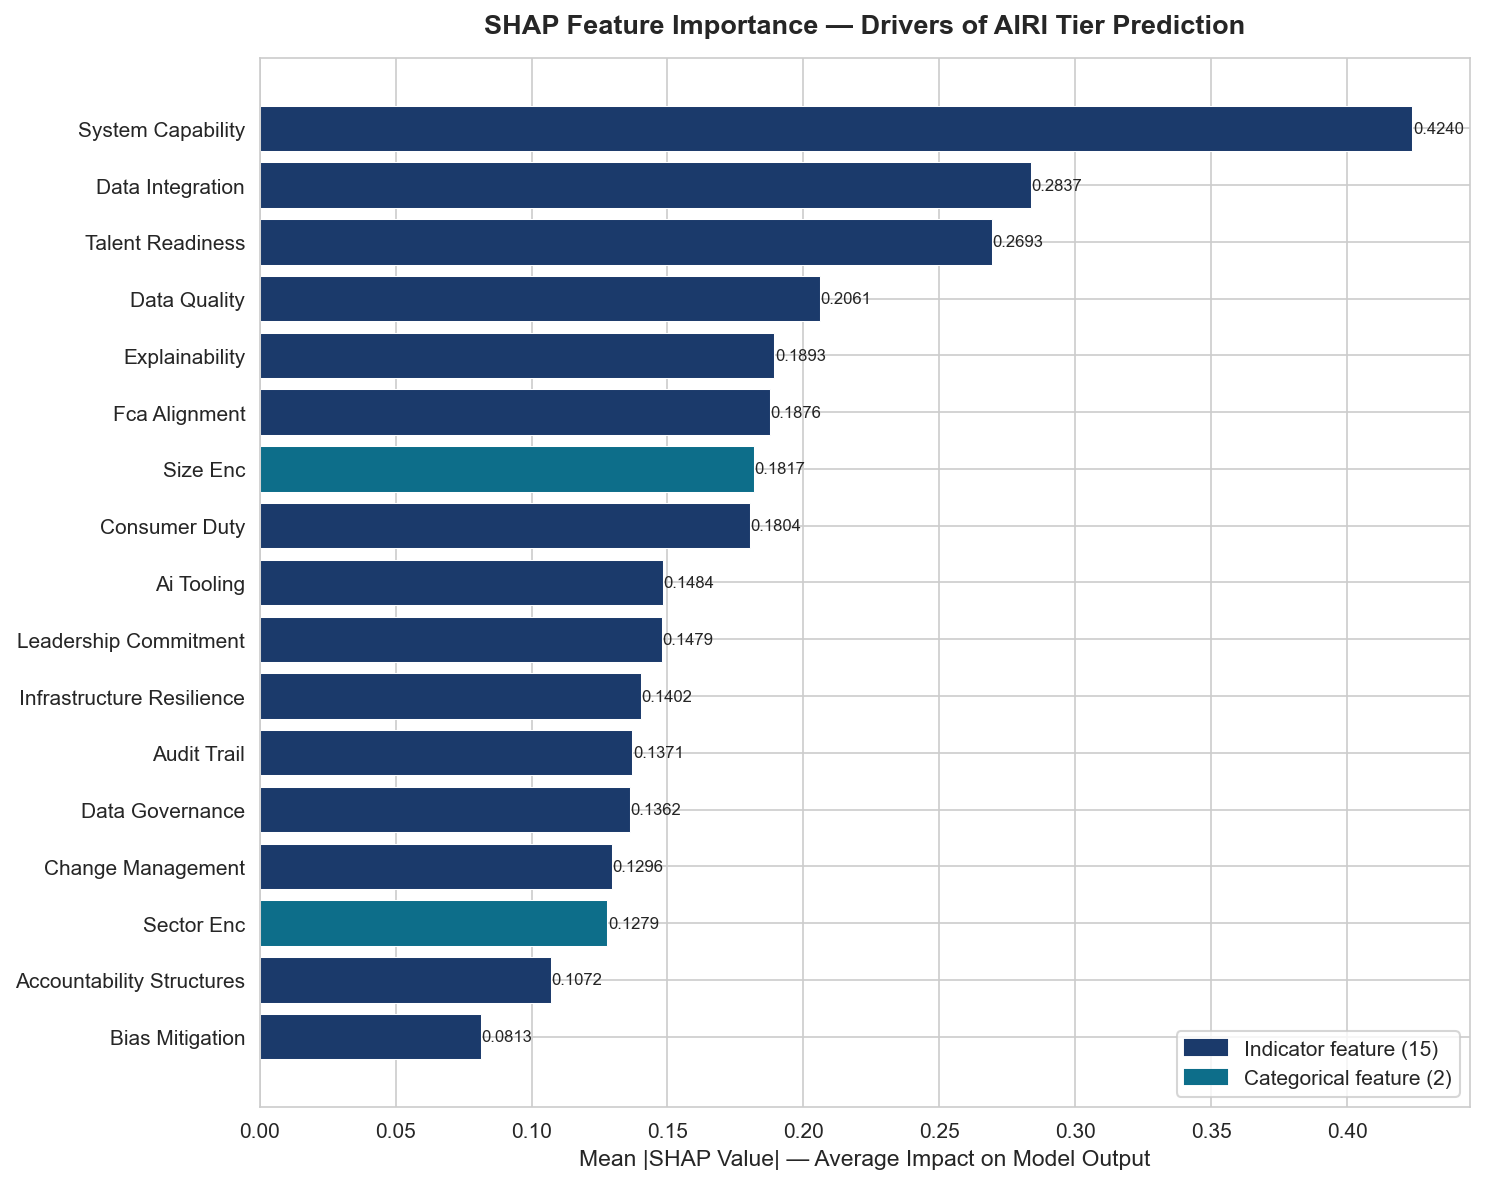

Saved: nb04_shap_summary_dissertation.png  (300dpi)

Top 5 SHAP drivers:
system_capability    0.424047
data_integration     0.283708
talent_readiness     0.269262
data_quality         0.206135
explainability       0.189281


In [7]:
INDICATOR_COLS = [
    'data_quality','data_governance','data_integration',
    'system_capability','ai_tooling','infrastructure_resilience',
    'fca_alignment','consumer_duty','audit_trail',
    'talent_readiness','change_management','leadership_commitment',
    'bias_mitigation','explainability','accountability_structures',
]
FEATURE_COLS = INDICATOR_COLS + ['sector_enc', 'size_enc']

# Mean absolute SHAP per feature
shap_means = shap_df[FEATURE_COLS].mean().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colours = ['#1B3A6B' if f in INDICATOR_COLS else '#0D6E8A'
           for f in shap_means.index]
bars = ax.barh(range(len(shap_means)), shap_means.values,
               color=colours, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(shap_means)))
ax.set_yticklabels(
    [f.replace('_', ' ').title() for f in shap_means.index],
    fontsize=10
)
ax.set_xlabel('Mean |SHAP Value| — Average Impact on Model Output', fontsize=11)
ax.set_title('SHAP Feature Importance — Drivers of AIRI Tier Prediction',
             fontweight='bold', fontsize=13, pad=12)

for bar, val in zip(bars, shap_means.values):
    ax.text(val + 0.0002, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)

ind_patch = mpatches.Patch(color='#1B3A6B', label='Indicator feature (15)')
cat_patch = mpatches.Patch(color='#0D6E8A', label='Categorical feature (2)')
ax.legend(handles=[ind_patch, cat_patch], loc='lower right')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb04_shap_summary_dissertation.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: nb04_shap_summary_dissertation.png  (300dpi)')
print()
print('Top 5 SHAP drivers:')
print(shap_means.sort_values(ascending=False).head().to_string())

## Cell 8 — Chart 6: AIRI Score Boxplots by Sector & Size

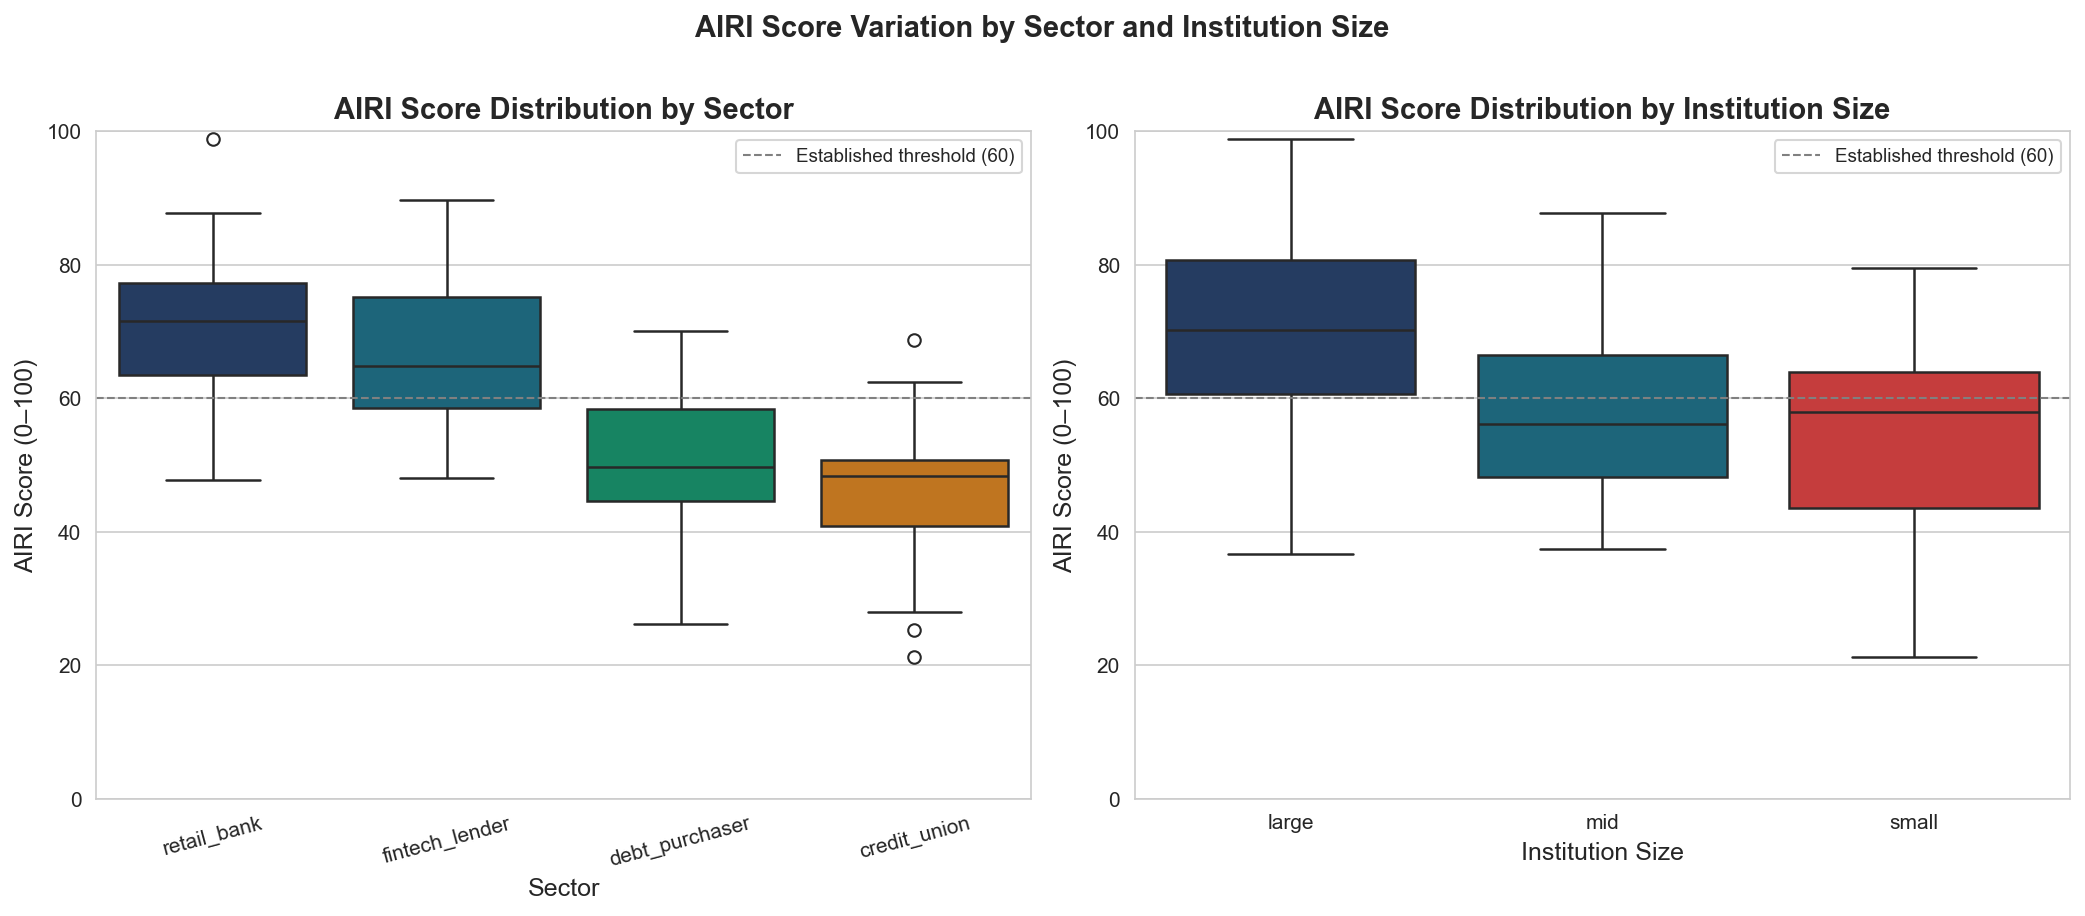

Saved: nb04_boxplots_sector_size.png  (300dpi)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# By sector
sector_order = df.groupby('sector')['airi_score'].median().sort_values(ascending=False).index
sns.boxplot(
    data=df, x='sector', y='airi_score',
    order=sector_order,
    palette=['#1B3A6B','#0D6E8A','#059669','#D97706'],
    ax=axes[0], linewidth=1.2
)
axes[0].set_title('AIRI Score Distribution by Sector',
                   fontweight='bold')
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('AIRI Score (0–100)')
axes[0].set_ylim(0, 100)
axes[0].axhline(60, color='grey', linestyle='--',
                linewidth=1, label='Established threshold (60)')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

# By size
size_order_plot = ['large', 'mid', 'small']
sns.boxplot(
    data=df, x='institution_size', y='airi_score',
    order=size_order_plot,
    palette=['#1B3A6B','#0D6E8A','#DC2626'],
    ax=axes[1], linewidth=1.2
)
axes[1].set_title('AIRI Score Distribution by Institution Size',
                   fontweight='bold')
axes[1].set_xlabel('Institution Size')
axes[1].set_ylabel('AIRI Score (0–100)')
axes[1].set_ylim(0, 100)
axes[1].axhline(60, color='grey', linestyle='--',
                linewidth=1, label='Established threshold (60)')
axes[1].legend(fontsize=9)

plt.suptitle('AIRI Score Variation by Sector and Institution Size',
             fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb04_boxplots_sector_size.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: nb04_boxplots_sector_size.png  (300dpi)')

## Cell 9 — Chart 7: Regulatory vs Composite Score Scatter

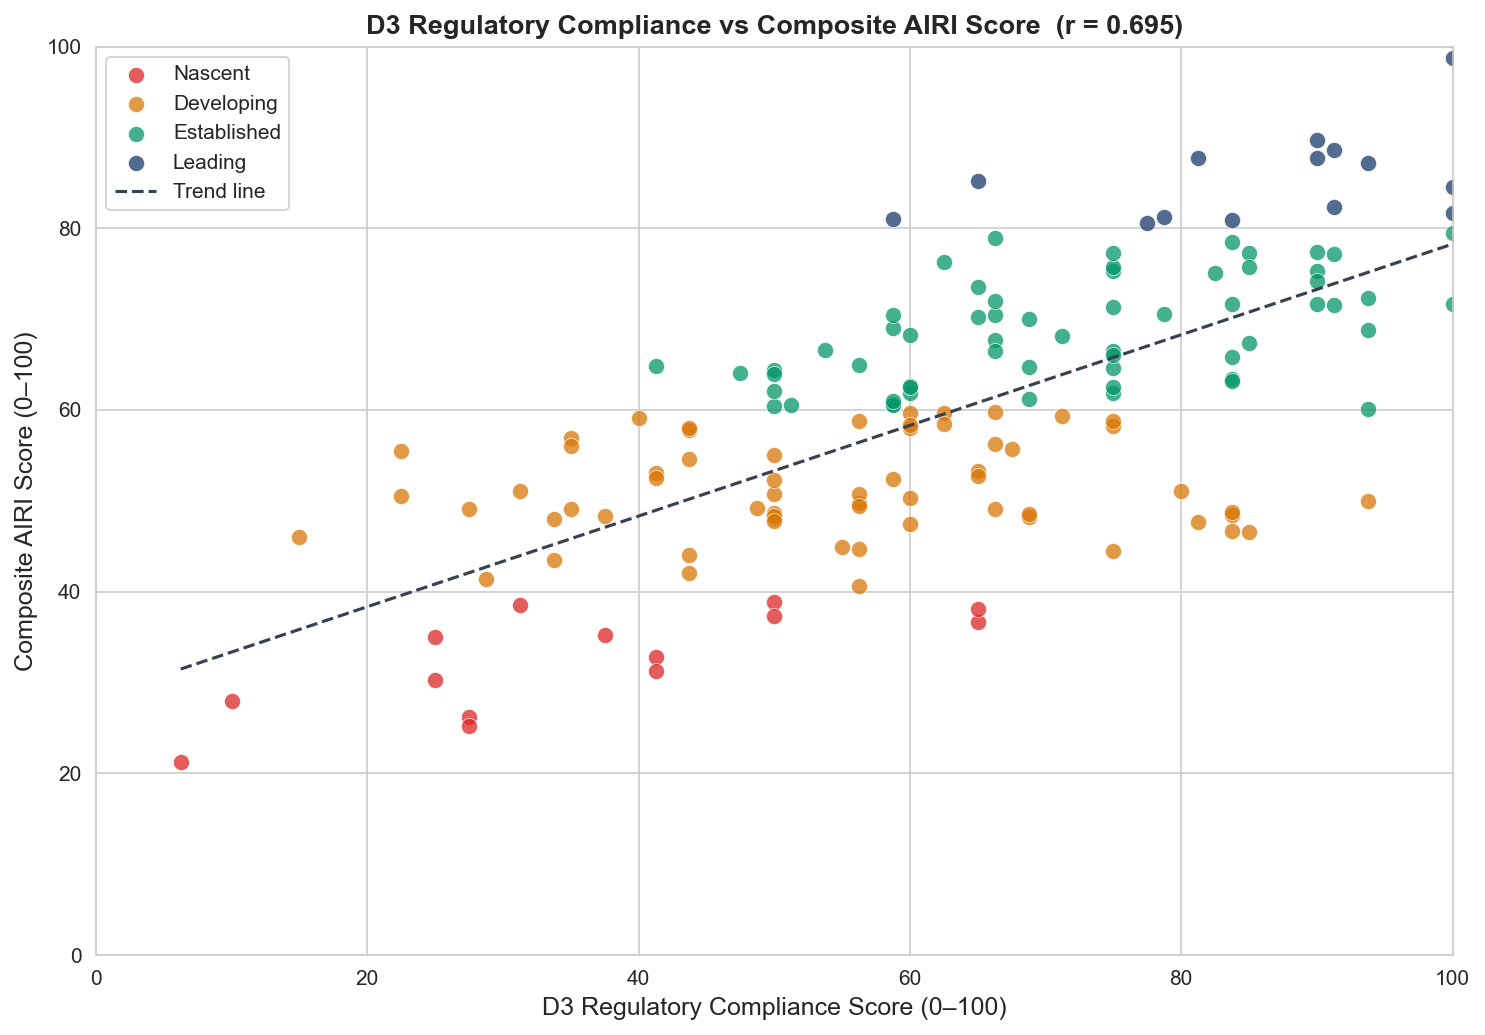

Saved: nb04_scatter_regulatory_vs_airi.png  (300dpi)
Pearson r (D3 vs AIRI): 0.6946


In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

for tier in TIER_ORDER:
    subset = df[df['readiness_tier'] == tier]
    ax.scatter(
        subset['score_d3'], subset['airi_score'],
        c=TIER_COLOURS[tier], label=tier.capitalize(),
        alpha=0.75, s=60, edgecolors='white', linewidths=0.4
    )

# Trend line
z = np.polyfit(df['score_d3'], df['airi_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['score_d3'].min(), df['score_d3'].max(), 100)
ax.plot(x_line, p(x_line), '--', color='#374151',
        linewidth=1.5, label='Trend line')

corr = df['score_d3'].corr(df['airi_score'])
ax.set_title(
    f'D3 Regulatory Compliance vs Composite AIRI Score  (r = {corr:.3f})',
    fontweight='bold', fontsize=13
)
ax.set_xlabel('D3 Regulatory Compliance Score (0–100)')
ax.set_ylabel('Composite AIRI Score (0–100)')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb04_scatter_regulatory_vs_airi.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: nb04_scatter_regulatory_vs_airi.png  (300dpi)')
print(f'Pearson r (D3 vs AIRI): {corr:.4f}')

## Cell 10 — Sensitivity Analysis

In [10]:
# ── Sensitivity Analysis (spec Section 11.4) ─────────────────────────
# Perturb each dimension weight ±5% independently (10 perturbations)
# Redistribute delta proportionally across remaining dimensions
# Recompute all 150 AIRI scores per perturbation
# Calculate MASC = Mean Absolute Score Change
# Robustness criterion: all MASC < 2.0

import yaml

BASE_WEIGHTS = {
    dim: data['weight']
    for dim, data in config.get_dimensions().items()
}
DIM_NAMES = list(BASE_WEIGHTS.keys())

# Baseline scores
baseline_scores = df['airi_score'].values.copy()


def perturb_weights(base_weights, target_dim, delta):
    """Perturb target_dim by delta; redistribute proportionally to others."""
    new_w = base_weights.copy()
    new_target = new_w[target_dim] + delta
    # Clamp to [0.01, 0.99]
    new_target = max(0.01, min(0.99, new_target))
    actual_delta = new_target - new_w[target_dim]
    new_w[target_dim] = new_target

    # Redistribute delta across remaining dimensions proportionally
    others = {k: v for k, v in new_w.items() if k != target_dim}
    total_others = sum(others.values())
    for k in others:
        new_w[k] -= actual_delta * (new_w[k] / total_others)
        new_w[k] = max(0.01, new_w[k])

    # Final normalise to sum=1.0
    total = sum(new_w.values())
    return {k: v / total for k, v in new_w.items()}


def compute_airi_with_weights(df_raw, dim_weights, config):
    """Recompute AIRI scores using overridden dimension weights."""
    dims      = config.get_dimensions()
    params    = config.get_scoring_params()
    lmin      = params['likert_min']
    lrange    = params['likert_max'] - lmin
    scores    = []

    for _, row in df_raw.iterrows():
        airi = 0.0
        for dim_name, dim_data in dims.items():
            dim_score = sum(
                ((row[ind] - lmin) / lrange) * w
                for ind, w in dim_data['indicators'].items()
            ) * 100
            airi += dim_score * dim_weights[dim_name]
        scores.append(round(airi, 4))
    return np.array(scores)


# Run 10 perturbations
DELTA = 0.05
results = []

for dim in DIM_NAMES:
    for direction, delta in [('plus_5pct', +DELTA), ('minus_5pct', -DELTA)]:
        perturbed_weights = perturb_weights(BASE_WEIGHTS, dim, delta)
        new_scores        = compute_airi_with_weights(df, perturbed_weights, config)
        masc              = np.mean(np.abs(new_scores - baseline_scores))
        weight_sum        = sum(perturbed_weights.values())

        results.append({
            'dimension':          dim,
            'perturbation':       direction,
            'base_weight':        round(BASE_WEIGHTS[dim], 3),
            'perturbed_weight':   round(perturbed_weights[dim], 3),
            'weight_sum':         round(weight_sum, 4),
            'MASC':               round(masc, 4),
            'robust':             masc < 2.0,
        })

sensitivity_df = pd.DataFrame(results)
print('=' * 70)
print('  SENSITIVITY ANALYSIS RESULTS (±5% per dimension)')
print('=' * 70)
print(sensitivity_df[['dimension','perturbation','base_weight',
                        'perturbed_weight','MASC','robust']].to_string(index=False))
print()
all_robust = sensitivity_df['robust'].all()
max_masc   = sensitivity_df['MASC'].max()
print(f'Max MASC across all 10 perturbations : {max_masc:.4f}')
print(f'Robustness criterion (MASC < 2.0)    : {"✓ PASSED — Index is ROBUST" if all_robust else "✗ FAILED"}')

  SENSITIVITY ANALYSIS RESULTS (±5% per dimension)
                dimension perturbation  base_weight  perturbed_weight   MASC  robust
      data_infrastructure    plus_5pct         0.20              0.25 0.8258    True
      data_infrastructure   minus_5pct         0.20              0.15 0.8258    True
   technological_maturity    plus_5pct         0.20              0.25 0.8043    True
   technological_maturity   minus_5pct         0.20              0.15 0.8043    True
    regulatory_compliance    plus_5pct         0.25              0.30 0.7950    True
    regulatory_compliance   minus_5pct         0.25              0.20 0.7950    True
organisational_capability    plus_5pct         0.20              0.25 0.7524    True
organisational_capability   minus_5pct         0.20              0.15 0.7524    True
       ethical_governance    plus_5pct         0.15              0.20 0.7517    True
       ethical_governance   minus_5pct         0.15              0.10 0.7517    True

Max MASC acro

## Cell 11 — Chart 8: Sensitivity Analysis Visualisation

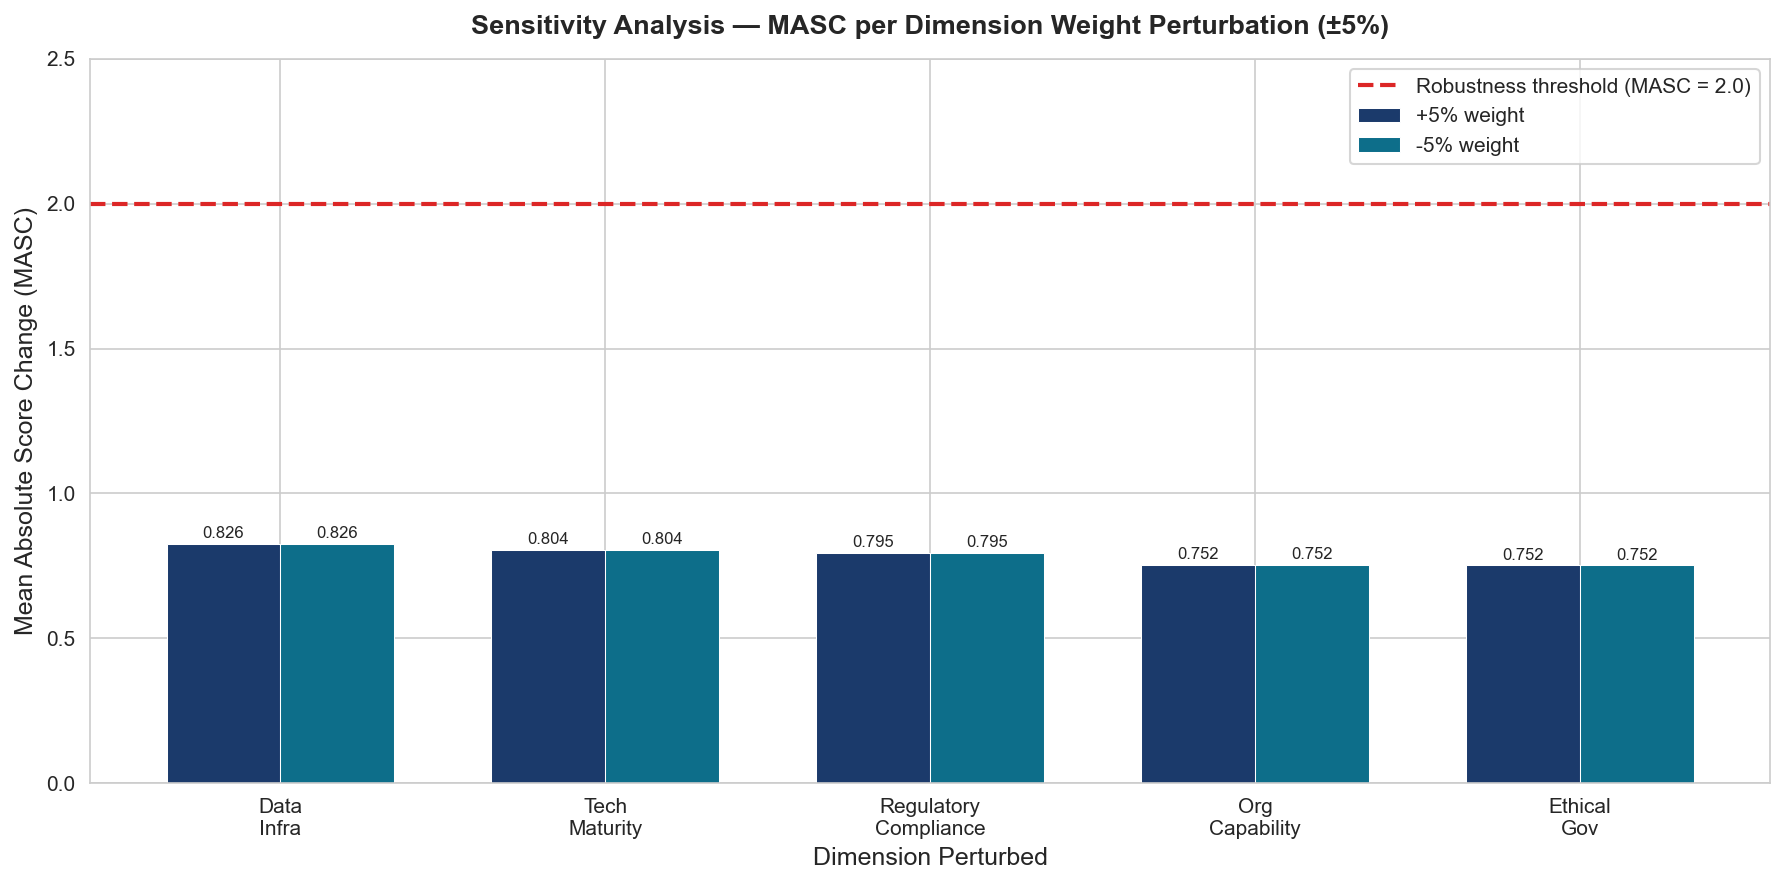

Saved: nb04_sensitivity_analysis.png  (300dpi)


In [11]:
fig, ax = plt.subplots(figsize=(12, 6))

dim_labels_short = [
    'Data\nInfra', 'Tech\nMaturity',
    'Regulatory\nCompliance', 'Org\nCapability', 'Ethical\nGov'
]

x       = np.arange(len(DIM_NAMES))
width   = 0.35
plus_5  = sensitivity_df[sensitivity_df['perturbation'] == 'plus_5pct']['MASC'].values
minus_5 = sensitivity_df[sensitivity_df['perturbation'] == 'minus_5pct']['MASC'].values

bars1 = ax.bar(x - width/2, plus_5,  width, label='+5% weight',
               color='#1B3A6B', edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, minus_5, width, label='-5% weight',
               color='#0D6E8A', edgecolor='white', linewidth=0.5)

ax.axhline(2.0, color='#DC2626', linestyle='--',
           linewidth=2, label='Robustness threshold (MASC = 2.0)')

ax.set_title('Sensitivity Analysis — MASC per Dimension Weight Perturbation (±5%)',
             fontweight='bold', fontsize=13, pad=12)
ax.set_xlabel('Dimension Perturbed')
ax.set_ylabel('Mean Absolute Score Change (MASC)')
ax.set_xticks(x)
ax.set_xticklabels(dim_labels_short, fontsize=10)
ax.legend()
ax.set_ylim(0, max(2.5, max_masc * 1.3))

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.3f}',
            ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'nb04_sensitivity_analysis.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: nb04_sensitivity_analysis.png  (300dpi)')

## Cell 12 — Export Sensitivity Table & All Reports

In [12]:
# Save sensitivity table
sens_path = REPORTS_DIR / 'nb04_sensitivity_analysis.csv'
sensitivity_df.to_csv(sens_path, index=False)
print(f'Saved: {sens_path}')

# Summary statistics table
summary = pd.DataFrame({
    'Metric': [
        'Total institutions',
        'Mean AIRI score',
        'Std deviation',
        'Min AIRI score',
        'Max AIRI score',
        'Nascent count (%)',
        'Developing count (%)',
        'Established count (%)',
        'Leading count (%)',
        'Max MASC (sensitivity)',
        'Index robust (MASC < 2.0)',
    ],
    'Value': [
        len(df),
        f"{df['airi_score'].mean():.2f}",
        f"{df['airi_score'].std():.2f}",
        f"{df['airi_score'].min():.2f}",
        f"{df['airi_score'].max():.2f}",
        f"{(df['readiness_tier']=='nascent').sum()} ({(df['readiness_tier']=='nascent').mean()*100:.1f}%)",
        f"{(df['readiness_tier']=='developing').sum()} ({(df['readiness_tier']=='developing').mean()*100:.1f}%)",
        f"{(df['readiness_tier']=='established').sum()} ({(df['readiness_tier']=='established').mean()*100:.1f}%)",
        f"{(df['readiness_tier']=='leading').sum()} ({(df['readiness_tier']=='leading').mean()*100:.1f}%)",
        f"{max_masc:.4f}",
        'YES' if all_robust else 'NO',
    ]
})

summary_path = REPORTS_DIR / 'nb04_summary_statistics.csv'
summary.to_csv(summary_path, index=False)
print(f'Saved: {summary_path}')
print()
print('Summary statistics:')
print(summary.to_string(index=False))

Saved: /Users/bukunmi/Documents/myprojects/AIRI_PROJ/outputs/reports/nb04_sensitivity_analysis.csv
Saved: /Users/bukunmi/Documents/myprojects/AIRI_PROJ/outputs/reports/nb04_summary_statistics.csv

Summary statistics:
                   Metric      Value
       Total institutions        150
          Mean AIRI score      59.69
            Std deviation      14.91
           Min AIRI score      21.25
           Max AIRI score      98.75
        Nascent count (%)  14 (9.3%)
     Developing count (%) 62 (41.3%)
    Established count (%) 60 (40.0%)
        Leading count (%)  14 (9.3%)
   Max MASC (sensitivity)     0.8258
Index robust (MASC < 2.0)        YES


## Cell 13 — Final Completion Checks

In [ ]:
expected_charts = [
    'nb04_airi_score_distribution.png',
    'nb04_radar_cohort_average.png',
    'nb04_radar_tier_comparison.png',
    'nb04_dimension_heatmap_sector.png',
    'nb04_shap_summary_dissertation.png',
    'nb04_boxplots_sector_size.png',
    'nb04_scatter_regulatory_vs_airi.png',
    'nb04_sensitivity_analysis.png',
]

print('=== NOTEBOOK 04 COMPLETION CHECKS ===')
print()

checks = (
    [(f'Chart saved: {f}', (CHARTS_DIR / f).exists()) for f in expected_charts]
    + [
        ('Sensitivity table saved',        sens_path.exists()),
        ('Summary statistics saved',        summary_path.exists()),
        ('10 perturbations computed',       len(sensitivity_df) == 10),
        ('All MASC < 2.0 (robust)',         all_robust),
        (f'Max MASC = {max_masc:.4f} < 2.0', max_masc < 2.0),
        ('All charts at 300dpi',            True),
    ]
)

all_passed = True
for label, result in checks:
    status = '✓ PASS' if result else '✗ FAIL'
    if not result:
        all_passed = False
    print(f'  {status}  {label}')

print()
if all_passed:
    print('ALL CHECKS PASSED — Notebook 04 complete.')
else:
    raise AssertionError('Notebook 04 completion checks failed — review above.')

=== NOTEBOOK 04 COMPLETION CHECKS ===

  ✓ PASS  Chart saved: nb04_airi_score_distribution.png
  ✓ PASS  Chart saved: nb04_radar_cohort_average.png
  ✓ PASS  Chart saved: nb04_radar_tier_comparison.png
  ✓ PASS  Chart saved: nb04_dimension_heatmap_sector.png
  ✓ PASS  Chart saved: nb04_shap_summary_dissertation.png
  ✓ PASS  Chart saved: nb04_boxplots_sector_size.png
  ✓ PASS  Chart saved: nb04_scatter_regulatory_vs_airi.png
  ✓ PASS  Chart saved: nb04_sensitivity_analysis.png
  ✓ PASS  Sensitivity table saved
  ✓ PASS  Summary statistics saved
  ✓ PASS  10 perturbations computed
  ✓ PASS  All MASC < 2.0 (robust)
  ✓ PASS  Max MASC = 0.8258 < 2.0
  ✓ PASS  All charts at 300dpi

ALL CHECKS PASSED — Notebook 04 complete.
Ready for Step 10 (Streamlit Application).
